# How to Build the ML Model
## First, we need to build our model. Here are the steps you should follow to do that.

### Import Python Packages
### We first import all the importance python packages that we will use to load the data, preprocess the data, and create a text classification model.

In [1]:
# import important modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from string import punctuation 

# sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,f1_score,roc_auc_score,classification_report

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

# text preprocessing modules
from nltk.tokenize import word_tokenize
from cleantext import clean

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
import re #regular expression


from wordcloud import WordCloud, STOPWORDS


# Load the Spam Dataset Then we load the spam dataset from the data directory, like this

In [2]:
#Download dependecy
for dependency in(
    "brown",
    "names",
    "wordnet",
    "averaged_perceptron_tagger",
    "universal_tagset",
    "stopwords"
):
    nltk.download(dependency)

#Dowload spam dataset
import warnings
warnings.filterwarnings("ignore")
# seeding
np.random.seed(123)

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package names to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rafaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to

In [3]:
# load data spam data
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

#Read the data
data = pd.read_csv(url,sep="\t",header=None,names=['label','message'])
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
data.shape

(5572, 2)

# How to Handle Missing Values
## Sometimes data can have missing values. We can use the isnull() method from pandas to check if our dataset has any missing values.

In [5]:
data.isna().sum()

label      0
message    0
dtype: int64

# How to Evaluate Class Distribution
## We can use the value_counts() method from the pandas package to evaluate the class distribution form our dataset

In [6]:
data["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
data = pd.DataFrame(data)
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Exploratory Data Analysis
* This is very important steps in creating your machine learning project. It helps you understand more about your dataset.

* In this step we are going to find frequent words that are used in both legitimate and spam messages.

In [8]:
# collect words from the dataset
def collect_words(data, label):
    collected_words = " "

    # iterate through the csv file
    for val in data.message[data["label"] == label]:

        # typecaste each val to string
        val = str(val)

        # split the value
        tokens = val.split()

        # Converts each token into lowercase
        for i in range(len(tokens)):
            tokens[i] = tokens[i].lower()

        for words in tokens:
            collected_words = collected_words + words + " "

    return collected_words

Total words 349132


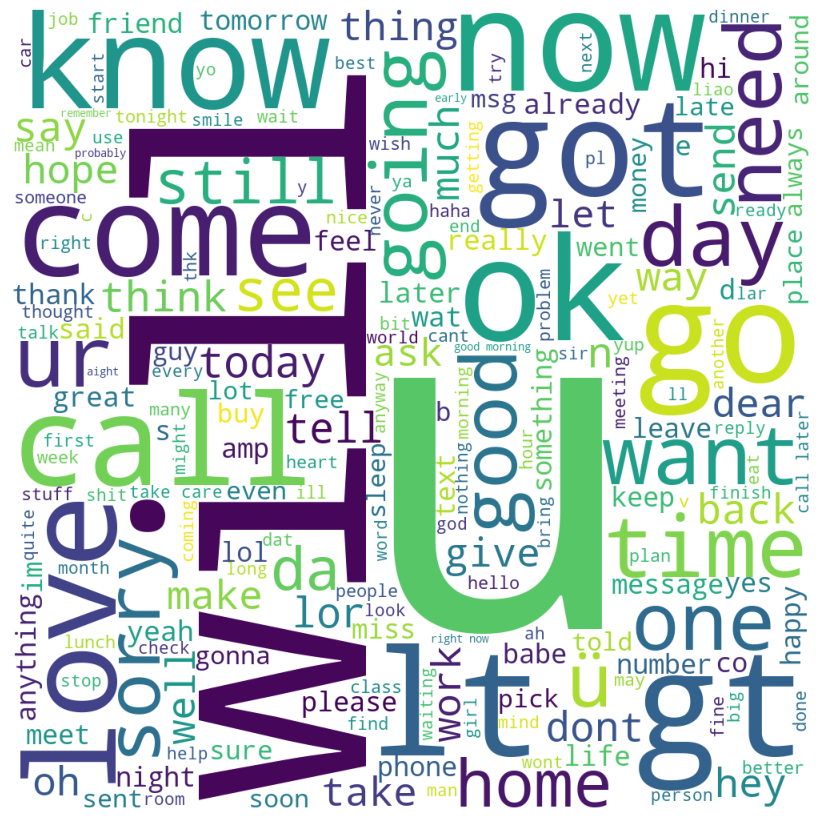

In [9]:
# visualize ham labeled sms
cloud_stopwords = set(STOPWORDS)
ham_words = collect_words(data, label="ham")

print("Total words {}".format(len(ham_words)))

wordcloud = WordCloud(
    width=1000,
    height=1000,
    background_color="white",
    stopwords=cloud_stopwords,
    min_font_size=10,
).generate(ham_words)

# plot the WordCloud image
plt.figure(figsize=(15, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

Total words 104304


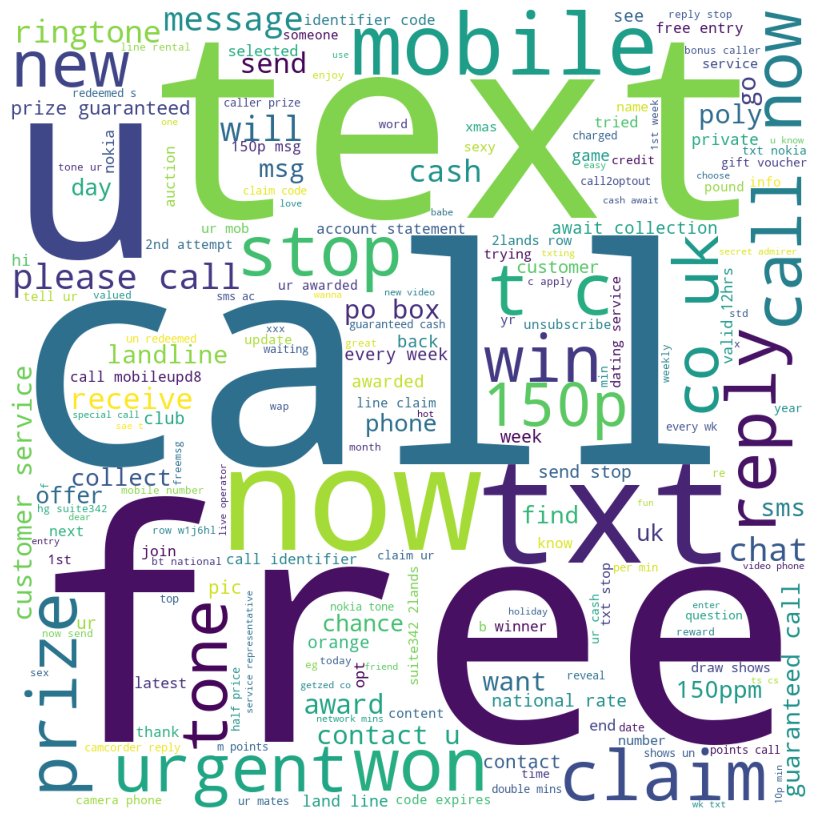

In [10]:
# visualize spam labeled sms
cloud_stopwords = set(STOPWORDS)
spam_words = collect_words(data, label="spam")

print("Total words {}".format(len(spam_words)))

wordcloud = WordCloud(
    width=1000,
    height=1000,
    background_color="white",
    stopwords=cloud_stopwords,
    min_font_size=10,
).generate(spam_words)

# plot the WordCloud image
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

### As you can see in the legit messages, the most frequent words are will, gt, now, ok, call, want, got, and so on.
### In the above figure it shows that the most frequent words are those like call, claim, free, txt, mobile, reply, offer and so on.

# How to Process the Data
## After exploring and analyzing the dataset, the next step is to preprocess the dataset into the right format before creating our machine learning model.

## We first replace the ham and spam classes with numerical values. The ham class will be labeled as 0 and spam class will be labeled as 1.

In [11]:
new_data = data.replace({'ham':0,'spam':1})
new_data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# The messages in this dataset contain a lot of unnecessary words and characters that we don't need when creating machine learning models.

## We will clean the messages by removing stopwords, numbers, and punctuation. Then we will change words into lower case, and finally convert each word into its base form by using the lemmatization process in the NLTK package.

### The `text_cleaning()` function will handle all necessary steps to clean our dataset.

In [12]:
stop_words = stopwords.words("english")

def text_cleaning(text,remove_stop_words=True,lemmatize_words=True):
    # Clean the text, with the option to remove stop_words and to lemmatize word

    # Clean the text
    text = re.sub(r"[^A-Za-z0-9]", " ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"I'm", "I am", text)
    text = re.sub(r"ur", " your ", text)
    text = re.sub(r" nd "," and ",text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r" tkts "," tickets ",text)
    text = re.sub(r" c "," can ",text)
    text = re.sub(r" e g ", " eg ", text)
    text =  re.sub(r'http\S+',' link ', text)
    text = re.sub(r'\b\d+(?:\.\d+)?\s+', '', text) # remove numbers
    text = re.sub(r" u "," you ",text)
    text = text.lower()  # set in lowercase 

    # Remove punctuation from text
    text = ''.join([c for c in text if c not in punctuation])

    # Optionally, remove stop words
    if remove_stop_words:
        text = text.split()
        text = [w for w in text if not w in stop_words]
        text = " ".join(text)

    # Optionally, shorten words to their stems
    if lemmatize_words:
        text = text.split()
        lemmatizer = WordNetLemmatizer() 
        lemmatized_words = [lemmatizer.lemmatize(word) for word in text]
        text = " ".join(lemmatized_words)

    # Return a list of words
    return(text)
    


In [13]:
#clean the dataset 
new_data["clean_message"] = new_data["message"].apply(text_cleaning)
new_data

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go j ong point crazy available bugis n great w...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final ticket 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,2nd time tried contact u pound prize claim eas...
5568,0,Will ü b going to esplanade fr home?,b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood suggestion
5570,0,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...


In [14]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    new_data["clean_message"],
    new_data["label"],
    test_size=0.15,
    random_state=0,
    shuffle=True,
    stratify=data["label"],
)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4736,), (836,), (4736,), (836,))

# The CountVectorizer method from scikit-learn will help us transform our cleaned dataset into numerical values. The method converts a collection of text documents to a matrix of token counts.

In [16]:
#Transform text data
vectorizer = CountVectorizer(lowercase=False)
vectorizer.fit(X_train)

#transform train data 
X_train_trans = vectorizer.transform(X_train)

#transform test data
X_text_trans = vectorizer.transform(X_test)

In [17]:
X_text_trans.shape, X_train_trans.shape

((836, 6873), (4736, 6873))

# How to Actually Create Our Model
## We will train the Multinomial Naive Bayes algorithm to classify if a message is legitimate or spam. This is one of the most common algorithms used for text classification.

In [18]:
#Model build
spam_classifier = MultinomialNB()

#Then we train our classifier by using cross validation to avoid overfitting.
scores = cross_val_score(spam_classifier,X_train_trans,list(y_train),cv=10,verbose=3,n_jobs=-1)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   40.3s finished


In [19]:
# find the mean of the all scores
scores.mean()

np.float64(0.9767713936539371)

`output: 0.9767713936539371`

`The mean of the scores is around 97.68%. Our model performs well, but we can improve its performance by optimizing its hyperparameter values with the Randomized Search method from scikit-learn.`

In [20]:
# fine turning model parameters

distribution = {"alpha": [1, 0.1, 0.01, 0.001, 0.0001, 0, 0.2, 0.3]}

grid = RandomizedSearchCV(
    spam_classifier,
    param_distributions=distribution,
    n_jobs=-1,
    cv=10,
    n_iter=20,
    random_state=42,
    return_train_score=True,
    verbose=2,
)

In [21]:
# training with randomized search
grid.fit(X_train_trans, list(y_train))

Fitting 10 folds for each of 8 candidates, totalling 80 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [1, 0.1, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score metho

In [22]:
# summarize the results of the random parameter search
print(grid.best_score_)
print(grid.best_estimator_)
print(grid.best_params_)

0.9767713936539371
MultinomialNB(alpha=1)
{'alpha': 1}


In [23]:
#Build your preidiction
# 1. Fit the vectorizer (You already did this part!)
vectorizer = CountVectorizer(lowercase=False)
vectorizer.fit(X_train)
X_train_trans = vectorizer.transform(X_train)
X_text_trans = vectorizer.transform(X_test)

# 2. INITIALIZE the classifier (if you haven't yet)
spam_classifier = MultinomialNB()

# 3. FIT the classifier (This is what was missing!)
spam_classifier.fit(X_train_trans, list(y_train))

# 4. NOW this will work!
test_pred = spam_classifier.predict(X_text_trans)

In [24]:
print(f"The score of test data our model\n{classification_report(y_true=list(y_test),y_pred=test_pred)}")

The score of test data our model
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       724
           1       0.93      0.88      0.91       112

    accuracy                           0.98       836
   macro avg       0.96      0.94      0.95       836
weighted avg       0.98      0.98      0.98       836



In [25]:
y_pred = spam_classifier.predict(X_train_trans)

print(f"The score of train data our model\n{classification_report(y_true=list(y_test),y_pred=test_pred)}")

The score of train data our model
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       724
           1       0.93      0.88      0.91       112

    accuracy                           0.98       836
   macro avg       0.96      0.94      0.95       836
weighted avg       0.98      0.98      0.98       836



In [26]:
import joblib

# Save the trained classifier
joblib.dump(spam_classifier, 'spam_classifier.pkl')

# Save the vectorizer (crucial! You need this to transform new text later)
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [27]:
# Load the saved components
loaded_classifier = joblib.load('spam_classifier.pkl')
loaded_vectorizer = joblib.load('vectorizer.pkl')

# New text you want to classify
new_emails = ["Congratulations you won a free prize!", "Hey, are we still meeting for lunch?"]

# 1. Transform the new text using the *loaded* vectorizer
new_emails_trans = loaded_vectorizer.transform(new_emails)

# 2. Predict using the *loaded* classifier
predictions = loaded_classifier.predict(new_emails_trans)

print(predictions)

[1 0]


# After creating our spam detection model, it's time to deploy it on the Algorithmia platform.

# What is Algorithmia?
## Algorithmia is a MLOps tool that provides a simple and faster way to deploy your machine learning model into production.

## Algorithmia specializes in "algorithms as a service". It allows users to create code snippets that run the ML model and host them on Algorithmia. Then you can call your code as an API.

## Now your model can be used for different applications of your choice, such as web apps, mobile apps, or e-commerce with a simple API call from Algorithmia.